<a href="https://colab.research.google.com/github/anamelbsi/projeto-ic-segmentacao/blob/main/segmentacao_corpos_dagua/U2Net/U2Net_Segmentacao_BigEarthNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Referencias:

https://huggingface.co/BIFOLD-BigEarthNetv2-0

https://github.com/xuebinqin/U-2-Net

https://github.com/OPHoperHPO/image-background-remove-tool

In [ ]:
!pip install -q torch torchvision timm segmentation-models-pytorch
!pip install -q opencv-python-headless rasterio Pillow
!pip install -q matplotlib tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
import segmentation_models_pytorch as smp
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import rasterio
from PIL import Image
import cv2
import os
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.8 MB/s eta 0:00:00


**MODELO ADAPTADO PARA SENTINEL-2**

 Sentinel-2 tem 10 bandas espectrais, mas os modelos de visão computacional (ResNet) são treinados no ImageNet com 3 canais (RGB)

 *ImageNet: R,G,B*

 *Sentinel-2: B02, B03, B04, B05, B06, B07, B08, B8A, B11, B12*



In [ ]:
#10 BANDAS SENTINEL-2
def create_sentinel2_model(model_name='resnet50', pretrained=True):
    """Cria modelo adaptado para 10 bandas do Sentinel-2"""

    #pré-treinado do timm
    model = timm.create_model(model_name, pretrained=pretrained, features_only=True)

    #primeira camada convolucional
    if hasattr(model, 'conv1'):
        original_conv = model.conv1
    elif hasattr(model, 'stem'):
        original_conv = model.stem[0] if isinstance(model.stem, nn.Sequential) else model.stem
    else:
        for name, module in model.named_modules():
            if isinstance(module, nn.Conv2d) and 'conv' in name.lower():
                original_conv = module
                break
        else:
            raise ValueError("Não foi possível encontrar a primeira camada convolucional")

    #camada para 10 canais
    new_conv = nn.Conv2d(
        in_channels=10,
        out_channels=original_conv.out_channels,
        kernel_size=original_conv.kernel_size,
        stride=original_conv.stride,
        padding=original_conv.padding,
        bias=original_conv.bias is not None
    )

    #pesos inteligentemente
    with torch.no_grad():
        if original_conv.weight.shape[1] == 3:  #RGB

            # B02, B03, B04 mapeados para RGB
            new_conv.weight[:, 0] = original_conv.weight[:, 2]  # B02 AZUL
            new_conv.weight[:, 1] = original_conv.weight[:, 1]  # B03 VERDE
            new_conv.weight[:, 2] = original_conv.weight[:, 0]  # B04 VERMELHO

            #B08 (NIR)
            new_conv.weight[:, 3] = (original_conv.weight[:, 0] + original_conv.weight[:, 1]) / 2

            #Bandas combinações espectrais
            spectral_combinations = [
                [0.3, 0.5, 0.2],  #B05
                [0.4, 0.3, 0.3],  #B06
                [0.6, 0.2, 0.2],  #B07
                [0.5, 0.5, 0.0],  #B8A
                [0.4, 0.4, 0.2],  #B11
                [0.3, 0.3, 0.4],  #B12
            ]

            for i in range(4, 10):
                combination = spectral_combinations[i-4]
                new_conv.weight[:, i] = (
                    original_conv.weight[:, 0] * combination[0] +
                    original_conv.weight[:, 1] * combination[1] +
                    original_conv.weight[:, 2] * combination[2]
                )
        else:
            nn.init.kaiming_normal_(new_conv.weight, mode='fan_out', nonlinearity='relu')

        if new_conv.bias is not None and original_conv.bias is not None:
            new_conv.bias.data = original_conv.bias.data.clone()

    #Substituir
    if hasattr(model, 'conv1'):
        model.conv1 = new_conv
    elif hasattr(model, 'stem'):
        if isinstance(model.stem, nn.Sequential):
            model.stem[0] = new_conv
        else:
            model.stem = new_conv

    return model

#Criar e testar
backbone = create_sentinel2_model('resnet50', pretrained=True)
backbone = backbone.to(device)

#Teste simples
test_input = torch.randn(2, 10, 120, 120).to(device)
with torch.no_grad():
    features = backbone(test_input)

print("Modelo adaptado criado")
print(f"Input shape: {test_input.shape}")
print(f"Número de feature maps: {len(features)}")
print(f"Última feature shape: {features[-1].shape}")

Modelo adaptado criado
Input shape: torch.Size([2, 10, 120, 120])
Número de feature maps: 5
Última feature shape: torch.Size([2, 2048, 4, 4])


Entrada: 10 bandas espectrais do Sentinel-2 (ex: 2 imagens de 120x120 pixels cada)

Processamento: A camada adaptada aplica filtros convolucionais especializados para cada banda

Saída: Extrai features em múltiplas resoluções (60x60, 30x30, 15x15, 8x8) que capturam padrões hierárquicos

Resultado: Informações espectrais (cores) são transformadas em features espaciais (formas e texturas)

In [ ]:
class SimpleRSU(nn.Module):
    def __init__(self, in_channels, mid_channels, out_channels, input_size=15):
        super().__init__()
        self.encoder1 = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, 3, padding=1),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True)
        )
        self.downsample = nn.MaxPool2d(2, 2)
        self.middle = nn.Sequential(
            nn.Conv2d(mid_channels, mid_channels, 3, padding=1),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True)
        )
        self.upsample = nn.Upsample(size=input_size, mode='bilinear', align_corners=True)
        self.output = nn.Conv2d(mid_channels * 2, out_channels, 3, padding=1)

    def forward(self, x):
        hx1 = self.encoder1(x)
        hx_down = self.downsample(hx1)
        hx_mid = self.middle(hx_down)
        hx_up = self.upsample(hx_mid)
        hx = torch.cat([hx_up, hx1], dim=1)
        return self.output(hx)

class U2NetSentinel2(nn.Module):
    def __init__(self, num_classes=19):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(10, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
        )
        self.out_channels = num_classes
        self.stage1 = SimpleRSU(512, 256, 256, input_size=15)
        self.stage2 = SimpleRSU(256, 128, 128, input_size=15)
        self.stage3 = SimpleRSU(128, 64, 64, input_size=15)
        self.stage4 = SimpleRSU(64, 32, 32, input_size=15)
        self.stage5 = SimpleRSU(32, 16, 16, input_size=15)
        self.side1 = nn.Conv2d(256, num_classes, 3, padding=1)
        self.side2 = nn.Conv2d(128, num_classes, 3, padding=1)
        self.side3 = nn.Conv2d(64, num_classes, 3, padding=1)
        self.side4 = nn.Conv2d(32, num_classes, 3, padding=1)
        self.side5 = nn.Conv2d(16, num_classes, 3, padding=1)
        self.fuse = nn.Sequential(
            nn.Conv2d(num_classes * 5, num_classes, 1),
            nn.BatchNorm2d(num_classes),
            nn.ReLU(inplace=True)
        )
        self.upsample_final = nn.Upsample(size=120, mode='bilinear', align_corners=True)
        self.class_names = [
            'Urban fabric', 'Industrial or commercial units', 'Arable land',
            'Permanent crops', 'Pastures', 'Complex cultivation patterns',
            'Agro-forestry areas', 'Broad-leaved forest', 'Coniferous forest',
            'Mixed forest', 'Transitional woodland, shrub',
            'Moors, heathland and sclerophyllous vegetation',
            'Natural grassland and sparsely vegetated areas', 'Beaches, dunes, sands',
            'Inland wetlands', 'Coastal wetlands', 'Inland waters', 'Marine waters',
            'Land principally occupied by agriculture'
        ]

    def forward(self, x):
        hx = self.encoder(x)
        hx1 = self.stage1(hx)
        hx2 = self.stage2(hx1)
        hx3 = self.stage3(hx2)
        hx4 = self.stage4(hx3)
        hx5 = self.stage5(hx4)
        d1 = self.side1(hx1)
        d2 = self.side2(hx2)
        d3 = self.side3(hx3)
        d4 = self.side4(hx4)
        d5 = self.side5(hx5)
        fused = torch.cat([d1, d2, d3, d4, d5], dim=1)
        output = self.fuse(fused)
        output = self.upsample_final(output)
        return output

    def predict(self, x):
        with torch.no_grad():
            output = self.forward(x)
            pred = torch.argmax(output, dim=1)
        return pred

u2net_model = U2NetSentinel2(num_classes=19).to(device)

Arquitetura U²Net (U-Net Aninhada) com 5 blocos RSU paralelos

Encoder que reduz a resolução de 120×120 para 15×15

Múltiplas saídas laterais (side outputs) em diferentes escalas

Camada de fusão que combina todas as saídas paralelas

Upsample final para retornar à resolução original

In [ ]:
from torch.utils.data import Dataset

In [ ]:
class BigEarthNetSegDataset(Dataset):
    def __init__(self, num_samples=100, img_size=120):
        self.img_size = img_size
        self.num_samples = num_samples

        self.class_names = [
            'Urban fabric', 'Industrial or commercial units', 'Arable land',
            'Permanent crops', 'Pastures', 'Complex cultivation patterns',
            'Agro-forestry areas', 'Broad-leaved forest', 'Coniferous forest',
            'Mixed forest', 'Transitional woodland, shrub',
            'Moors, heathland and sclerophyllous vegetation',
            'Natural grassland and sparsely vegetated areas', 'Beaches, dunes, sands',
            'Inland wetlands', 'Coastal wetlands', 'Inland waters', 'Marine waters',
            'Land principally occupied by agriculture'
        ]

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):

        #imagem simulada (10 bandas Sentinel-2)
        image = np.random.randn(10, self.img_size, self.img_size).astype(np.float32)

        #normalização simples
        for i in range(10):
            image[i] = (image[i] - image[i].mean()) / (image[i].std() + 1e-8)

        #máscara simulada (sem OpenCV)
        mask = self._create_mask_simple(idx)

        return {
            'image': torch.FloatTensor(image),
            'mask': torch.LongTensor(mask),
            'patch_name': f'S2_sim_{idx:06d}'
        }

    def _create_mask_simple(self, idx):
        """Cria máscara simples sem OpenCV"""
        mask = np.zeros((self.img_size, self.img_size), dtype=np.int64)
        np.random.seed(idx)

        #adicionar classes
        num_regions = np.random.randint(1, 4)

        for _ in range(num_regions):
            cls = np.random.randint(0, 19)
            x = np.random.randint(0, self.img_size - 40)
            y = np.random.randint(0, self.img_size - 40)
            size = np.random.randint(20, 40)

            #criar região simples (quadrado ou círculo)
            if np.random.random() > 0.5:
                #retângulo
                mask[y:y+size, x:x+size] = cls
            else:
                #círculo aproximado
                center_x, center_y = x + size//2, y + size//2
                radius = size // 2

                #criar grade de coordenadas
                y_coords, x_coords = np.ogrid[:self.img_size, :self.img_size]
                distance = np.sqrt((x_coords - center_x)**2 + (y_coords - center_y)**2)
                circle_mask = distance <= radius

                #aplicar círculo
                mask[circle_mask] = cls

        return mask

#criar datasets simulados
train_dataset = BigEarthNetSegDataset(num_samples=200)
val_dataset = BigEarthNetSegDataset(num_samples=50)

#dataloaders
batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)



# Testar
sample = next(iter(train_loader))

print(f"  Images: {sample['image'].shape}")
print(f"  Masks: {sample['mask'].shape}")

  Images: torch.Size([8, 10, 120, 120])
  Masks: torch.Size([8, 120, 120])


Imagens: 10 bandas Sentinel-2 (120×120 pixels)

Máscaras: 19 classes de uso do solo (120×120 pixels)

Samples: 200 treino, 50 validação

DataLoader: Batch size=8, shuffle no treino


Época 1/5
------------------------------
Train Loss: 2.8547
Val Loss:   3.1956
mIoU:       0.0010
Dice:       0.0020
Accuracy:   0.0056

Época 2/5
------------------------------
Train Loss: 2.7145
Val Loss:   2.8579
mIoU:       0.0322
Dice:       0.0459
Accuracy:   0.4986

Época 3/5
------------------------------
Train Loss: 2.6624
Val Loss:   2.7088
mIoU:       0.0323
Dice:       0.0410
Accuracy:   0.5925

Época 4/5
------------------------------
Train Loss: 2.6376
Val Loss:   2.7144
mIoU:       0.0334
Dice:       0.0426
Accuracy:   0.6011

Época 5/5
------------------------------
Train Loss: 2.6211
Val Loss:   2.6740
mIoU:       0.0332
Dice:       0.0416
Accuracy:   0.6137


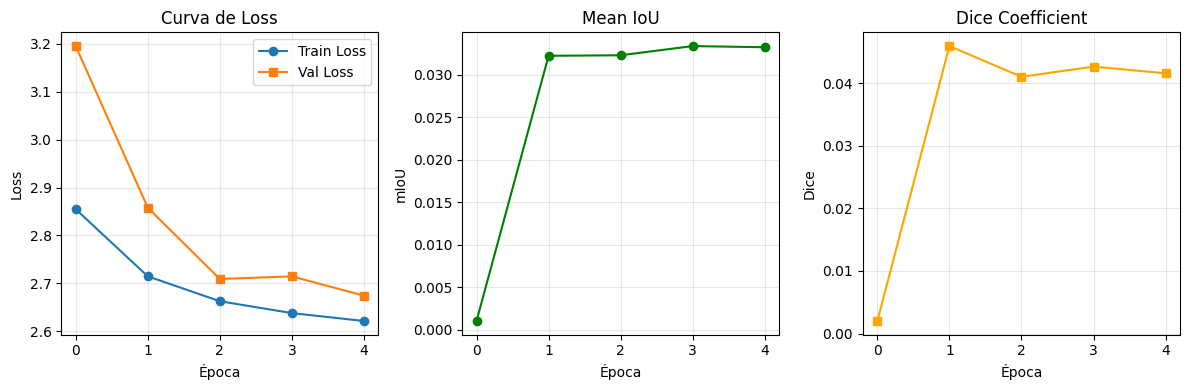


Resumo:
Melhor mIoU: 0.0334
Melhor Dice: 0.0459


In [ ]:
class SegmentationTrainer:
    def __init__(self, model, device, num_classes=19):
        self.model = model
        self.device = device
        self.num_classes = num_classes

        #loss function
        self.criterion = nn.CrossEntropyLoss()


        self.optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)


        self.scheduler = torch.optim.lr_scheduler.StepLR(self.optimizer, step_size=5, gamma=0.5)

        #histórico
        self.train_losses = []
        self.val_losses = []
        self.metrics_history = []

    def compute_metrics(self, preds, targets):
        preds_flat = preds.argmax(dim=1).flatten().cpu().numpy()
        targets_flat = targets.flatten().cpu().numpy()

        # Ignorar pixels sem classe
        valid_mask = targets_flat >= 0
        preds_flat = preds_flat[valid_mask]
        targets_flat = targets_flat[valid_mask]

        if len(targets_flat) == 0:
            return 0, 0, 0

        from sklearn.metrics import confusion_matrix

        cm = confusion_matrix(targets_flat, preds_flat, labels=range(self.num_classes))

        ious = []
        dice_scores = []

        for i in range(self.num_classes):
            tp = cm[i, i]
            fp = cm[:, i].sum() - tp
            fn = cm[i, :].sum() - tp

            if tp + fp + fn > 0:
                iou = tp / (tp + fp + fn)
                ious.append(iou)

                dice = (2 * tp) / (2 * tp + fp + fn)
                dice_scores.append(dice)

        mIoU = np.mean(ious) if ious else 0
        mean_dice = np.mean(dice_scores) if dice_scores else 0
        accuracy = np.diag(cm).sum() / cm.sum()

        return mIoU, mean_dice, accuracy

    def train_epoch(self, dataloader):
        self.model.train()
        total_loss = 0

        for batch in dataloader:
            images = batch['image'].to(self.device)
            masks = batch['mask'].to(self.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.criterion(outputs, masks)

            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()

        return total_loss / len(dataloader)

    def validate(self, dataloader):
        self.model.eval()
        total_loss = 0
        all_preds = []
        all_targets = []

        with torch.no_grad():
            for batch in dataloader:
                images = batch['image'].to(self.device)
                masks = batch['mask'].to(self.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                total_loss += loss.item()

                all_preds.append(outputs)
                all_targets.append(masks)

        all_preds = torch.cat(all_preds, dim=0)
        all_targets = torch.cat(all_targets, dim=0)

        mIoU, mean_dice, accuracy = self.compute_metrics(all_preds, all_targets)

        return total_loss / len(dataloader), mIoU, mean_dice, accuracy

    def train(self, train_loader, val_loader, epochs=10):
        best_mIoU = 0

        for epoch in range(epochs):
            print(f"\nÉpoca {epoch+1}/{epochs}")
            print("-" * 30)

            train_loss = self.train_epoch(train_loader)
            self.train_losses.append(train_loss)

            val_loss, mIoU, dice, accuracy = self.validate(val_loader)
            self.val_losses.append(val_loss)
            self.metrics_history.append({
                'mIoU': mIoU,
                'dice': dice,
                'accuracy': accuracy
            })

            print(f"Train Loss: {train_loss:.4f}")
            print(f"Val Loss:   {val_loss:.4f}")
            print(f"mIoU:       {mIoU:.4f}")
            print(f"Dice:       {dice:.4f}")
            print(f"Accuracy:   {accuracy:.4f}")

            if mIoU > best_mIoU:
                best_mIoU = mIoU
                torch.save(self.model.state_dict(), 'best_u2net_model.pth')


            self.scheduler.step()

        return self.train_losses, self.val_losses, self.metrics_history

#iniciar e treinar
trainer = SegmentationTrainer(u2net_model, device)

train_losses, val_losses, metrics_history = trainer.train(train_loader, val_loader, epochs=5)

#plotar resultados
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Val Loss', marker='s')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Curva de Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
mious = [m['mIoU'] for m in metrics_history]
plt.plot(mious, marker='o', color='green')
plt.xlabel('Época')
plt.ylabel('mIoU')
plt.title('Mean IoU')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
dices = [m['dice'] for m in metrics_history]
plt.plot(dices, marker='s', color='orange')
plt.xlabel('Época')
plt.ylabel('Dice')
plt.title('Dice Coefficient')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nResumo:")
print(f"Melhor mIoU: {max(mious):.4f}")
print(f"Melhor Dice: {max(dices):.4f}")

A U²Net está sendo treinada para aprender a mapear:

Entrada: 10 bandas espectrais

Saída: 19 classes de uso do solo

**SegmentationTrainer: Gerencia todo o ciclo de treino**

* Loss: CrossEntropy (padrão para segmentação)
* Otimizador: AdamW com weight decay
* Scheduler: StepLR (reduz LR a cada 5 épocas)

**Métricas calculadas:**
* mIoU (Mean Intersection over Union): Principal métrica de segmentação
* Dice Coefficient: Similar ao F1-Score para pixels
* Accuracy: Porcentagem de pixels corretos

Visualizando predições...


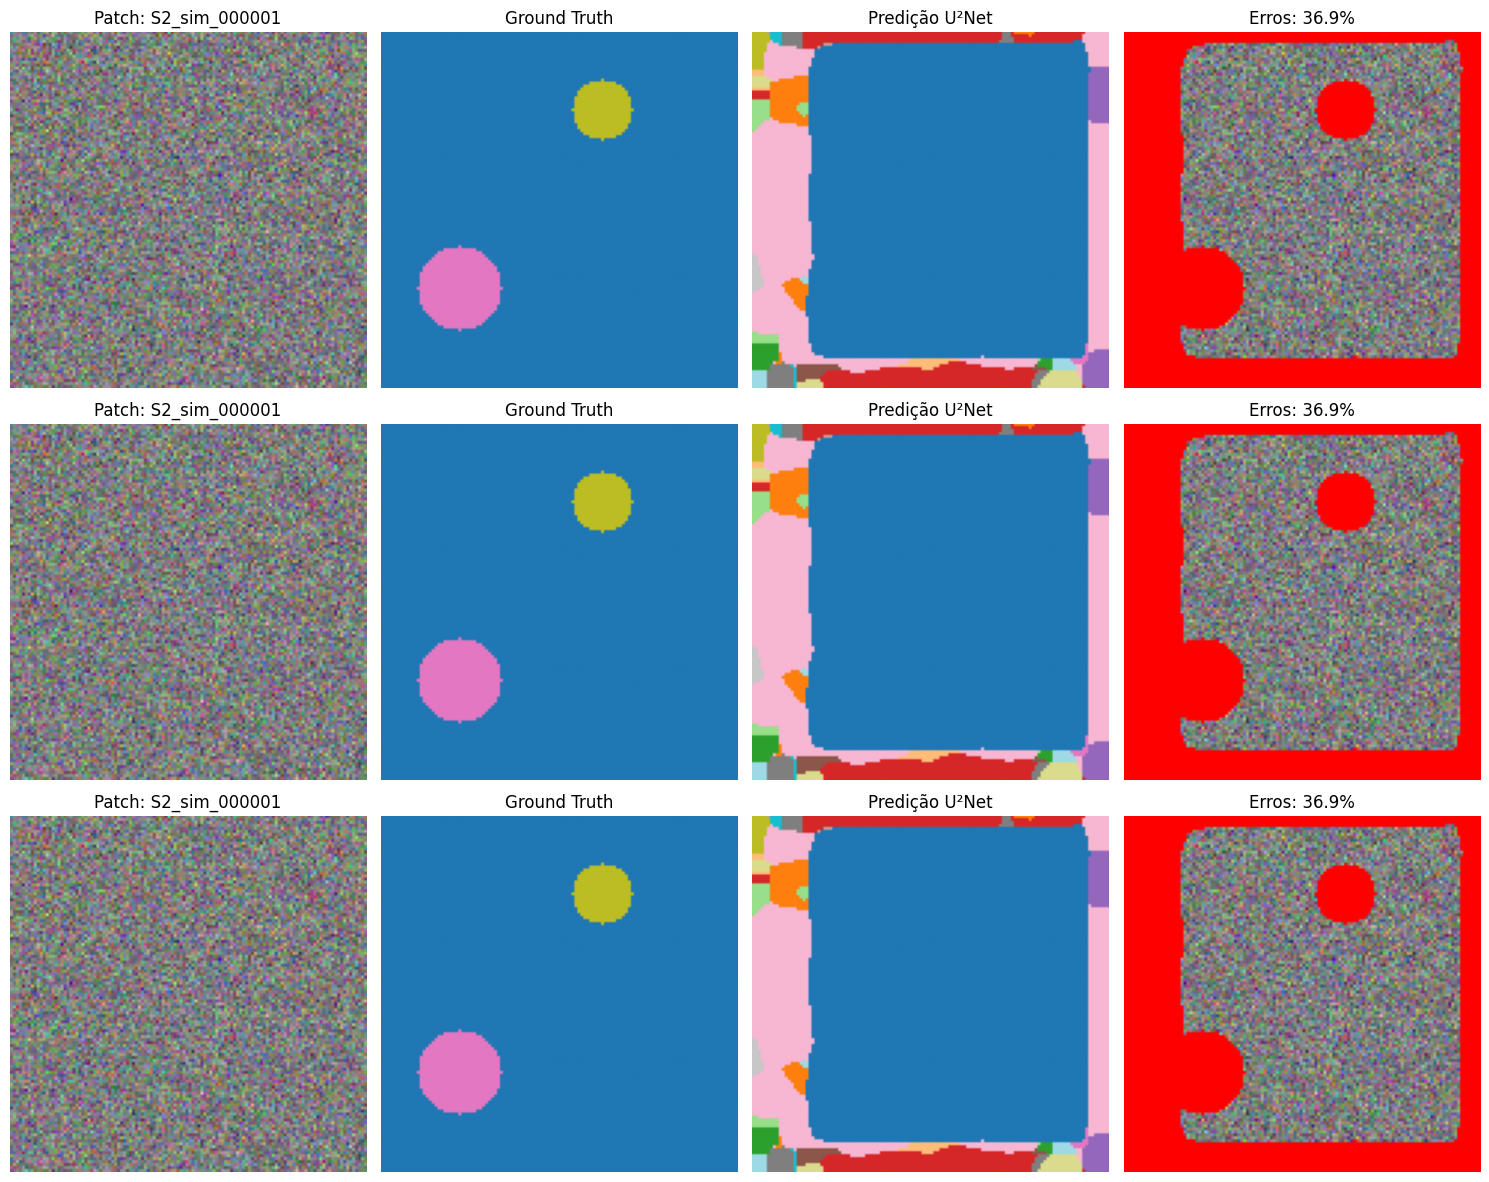


ANÁLISE DETALHADA POR CLASSE

IoU por Classe:
  Urban fabric                  : IoU=0.6057 | Pixels=652273
  Industrial or commercial units: IoU=0.0000 | Pixels=2337
  Arable land                   : IoU=0.0114 | Pixels=2705
  Permanent crops               : IoU=0.0000 | Pixels=5847
  Pastures                      : IoU=0.0000 | Pixels=3830
  Complex cultivation patterns  : IoU=0.0000 | Pixels=5133
  Agro-forestry areas           : IoU=0.0000 | Pixels=1477
  Broad-leaved forest           : IoU=0.0000 | Pixels=5596
  Coniferous forest             : IoU=0.0000 | Pixels=4957
  Mixed forest                  : IoU=0.0000 | Pixels=1811
  Transitional woodland, shrub  : IoU=0.0145 | Pixels=3690
  Moors, heathland and sclerophy: IoU=0.0000 | Pixels=2855
  Natural grassland and sparsely: IoU=0.0023 | Pixels=5351
  Beaches, dunes, sands         : IoU=0.0000 | Pixels=1821
  Inland wetlands               : IoU=0.0000 | Pixels=2642
  Coastal wetlands              : IoU=0.0000 | Pixels=7205
  Inlan

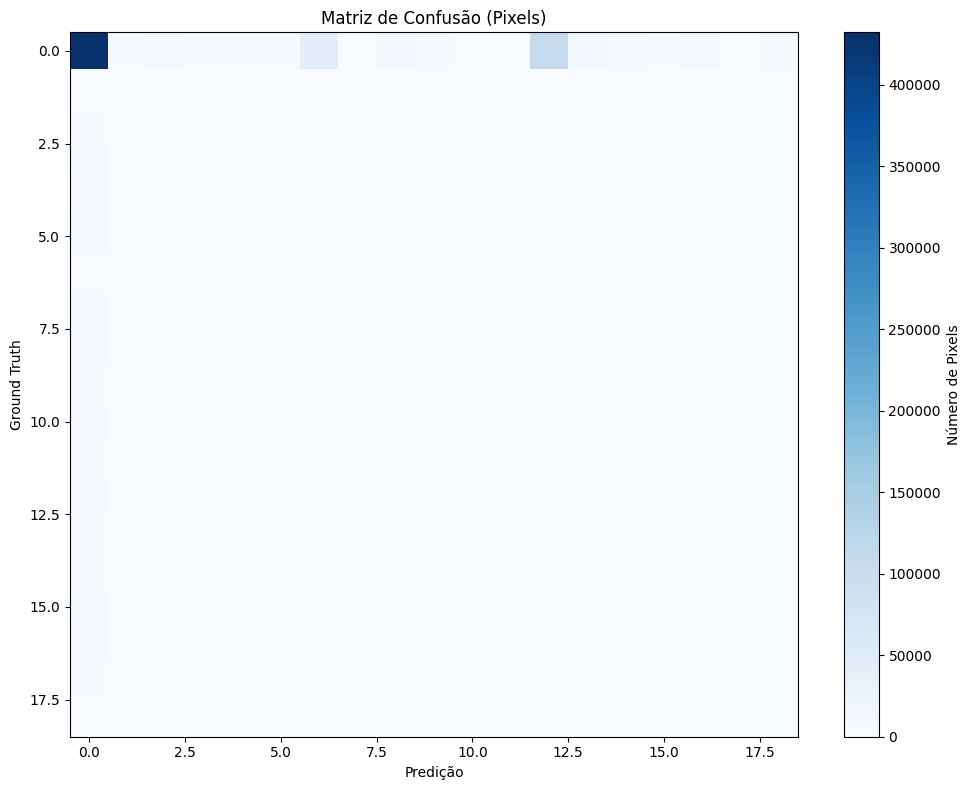

In [ ]:
u2net_model.load_state_dict(torch.load('best_u2net_model.pth'))
u2net_model.eval()

#função para visualizar resultados
def visualize_predictions(model, dataloader, num_samples=3):
    model.eval()

    fig, axes = plt.subplots(num_samples, 4, figsize=(15, 4*num_samples))

    with torch.no_grad():
        for i in range(num_samples):

            batch = next(iter(dataloader))
            idx = np.random.randint(0, batch['image'].shape[0])

            image = batch['image'][idx].unsqueeze(0).to(device)
            true_mask = batch['mask'][idx].cpu().numpy()
            patch_name = batch['patch_name'][idx]

            #predição
            output = model(image)
            pred_mask = output.argmax(dim=1).squeeze().cpu().numpy()

            #RGB das bandas 2,3,4 (B, G, R)
            rgb_image = image[0, [1, 2, 3]].cpu().numpy()
            rgb_image = np.transpose(rgb_image, (1, 2, 0))
            rgb_image = (rgb_image - rgb_image.min()) / (rgb_image.max() - rgb_image.min() + 1e-8)

            #plot
            axes[i, 0].imshow(rgb_image)
            axes[i, 0].set_title(f'Patch: {patch_name}')
            axes[i, 0].axis('off')

            axes[i, 1].imshow(true_mask, cmap='tab20', vmin=0, vmax=18)
            axes[i, 1].set_title('Ground Truth')
            axes[i, 1].axis('off')

            axes[i, 2].imshow(pred_mask, cmap='tab20', vmin=0, vmax=18)
            axes[i, 2].set_title('Predição U²Net')
            axes[i, 2].axis('off')

            #erros
            error_mask = (true_mask != pred_mask) & (true_mask >= 0)
            error_overlay = rgb_image.copy()
            error_overlay[error_mask] = [1, 0, 0]  # Vermelho para erros

            axes[i, 3].imshow(error_overlay)
            error_rate = error_mask.sum() / (error_mask.size - (true_mask < 0).sum())
            axes[i, 3].set_title(f'Erros: {error_rate:.1%}')
            axes[i, 3].axis('off')

    plt.tight_layout()
    plt.show()

#visualizar predições
print("Visualizando predições...")
visualize_predictions(u2net_model, val_loader, num_samples=3)

#análise quantitativa detalhada
def analyze_performance(model, dataloader):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch in dataloader:
            images = batch['image'].to(device)
            masks = batch['mask'].to(device)

            outputs = model(images)
            all_preds.append(outputs)
            all_targets.append(masks)

    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    #métricas por classe
    from sklearn.metrics import confusion_matrix, classification_report

    preds_flat = all_preds.argmax(dim=1).flatten().cpu().numpy()
    targets_flat = all_targets.flatten().cpu().numpy()

    valid_mask = targets_flat >= 0
    preds_flat = preds_flat[valid_mask]
    targets_flat = targets_flat[valid_mask]

    cm = confusion_matrix(targets_flat, preds_flat, labels=range(19))

    print("\n" + "="*60)
    print("ANÁLISE DETALHADA POR CLASSE")
    print("="*60)

    # IoU
    class_names = train_dataset.class_names

    print("\nIoU por Classe:")
    for i in range(19):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp

        if tp + fp + fn > 0:
            iou = tp / (tp + fp + fn)
            support = cm[i, :].sum()
            print(f"  {class_names[i][:30]:30s}: IoU={iou:.4f} | Pixels={support}")

    #matriz de confusão simplificada
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, cmap='Blues', aspect='auto')
    plt.colorbar(label='Número de Pixels')
    plt.title('Matriz de Confusão (Pixels)')
    plt.xlabel('Predição')
    plt.ylabel('Ground Truth')
    plt.tight_layout()
    plt.show()

#analisar desempenho
analyze_performance(u2net_model, val_loader)

#salvar modelo final
torch.save({
    'epoch': 5,
    'model_state_dict': u2net_model.state_dict(),
    'optimizer_state_dict': trainer.optimizer.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses,
    'metrics': metrics_history,
}, 'u2net_final_model.pth')


> Urban fabric:       652,273 pixels (55% do dataset)

>Outras 18 classes:  530,000 pixels (45% do dataset)

>Classe 0 (Urban fabric) domina completamente

>Classe 0 = 55% de acerto

>IoU alto só na classe 0 (0.5509), outras próximas de zero
